In [1]:
import sys
sys.path.append('../../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Date curate
df = pd.read_csv('../../data/processed/WineDataset_clean.csv')

# Embeddings de la profesor
emb_small = np.load('../../data/processed/WineDataset_iarina_full_Qwen_Qwen3-Embedding-0.6B.npy')
emb_big   = np.load('../../data/processed/WineDataset_iarina_full_Qwen_Qwen3-Embedding-8B.npy')

print(f"Dataset shape: {df.shape}")
print(f"Embeddings 0.6B shape: {emb_small.shape}")
print(f"Embeddings 8B shape: {emb_big.shape}")

Dataset shape: (1286, 12)
Embeddings 0.6B shape: (1286, 1024)
Embeddings 8B shape: (1286, 4096)


In [3]:
# Define features
cat_cols = ['Capacity', 'Grape', 'Closure', 'Country', 'Type', 'Region', 'Style', 'Vintage']
num_cols = ['ABV']
target = 'Price_log'

X_tab = df[cat_cols + num_cols]
y = df[target]

# Same random_state for fair comparison!
X_train_idx, X_test_idx = train_test_split(df.index, test_size=0.2, random_state=42)

X_train_tab = X_tab.loc[X_train_idx]
X_test_tab = X_tab.loc[X_test_idx]
y_train = y.loc[X_train_idx]
y_test = y.loc[X_test_idx]

emb_small_train = emb_small[X_train_idx]
emb_small_test = emb_small[X_test_idx]
emb_big_train = emb_big[X_train_idx]
emb_big_test = emb_big[X_test_idx]

# Tabular preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols),
    ('num', 'passthrough', num_cols)
])
X_train_tab_enc = preprocessor.fit_transform(X_train_tab)
X_test_tab_enc = preprocessor.transform(X_test_tab)

# Helper function
def evaluate(name, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
    print(f"=== {name} ===")
    print(f"R²: {r2:.4f} | RMSE (£): {rmse:.2f}")
    return r2, rmse

results = {}

print(f"Train size: {len(X_train_idx)}")
print(f"Test size: {len(X_test_idx)}")

Train size: 1028
Test size: 258


In [4]:
# --- Tabular only (referinta) ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_tab_enc, y_train)
r2, rmse = evaluate("Tabular only", y_test, rf.predict(X_test_tab_enc))
results['Tabular only'] = (r2, rmse)

# --- 0.6B: Tabular + Embeddings ---
X_train_c = sp.hstack([X_train_tab_enc, sp.csr_matrix(emb_small_train)])
X_test_c = sp.hstack([X_test_tab_enc, sp.csr_matrix(emb_small_test)])
rf2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X_train_c, y_train)
r2, rmse = evaluate("0.6B: Tabular + Embeddings", y_test, rf2.predict(X_test_c))
results['0.6B: Tabular + Embeddings'] = (r2, rmse)

# --- 0.6B: Embeddings only ---
rf3 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf3.fit(emb_small_train, y_train)
r2, rmse = evaluate("0.6B: Embeddings only", y_test, rf3.predict(emb_small_test))
results['0.6B: Embeddings only'] = (r2, rmse)

# --- 8B: Tabular + Embeddings ---
X_train_b = sp.hstack([X_train_tab_enc, sp.csr_matrix(emb_big_train)])
X_test_b = sp.hstack([X_test_tab_enc, sp.csr_matrix(emb_big_test)])
rf4 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf4.fit(X_train_b, y_train)
r2, rmse = evaluate("8B: Tabular + Embeddings", y_test, rf4.predict(X_test_b))
results['8B: Tabular + Embeddings'] = (r2, rmse)

# --- 8B: Embeddings only ---
rf5 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf5.fit(emb_big_train, y_train)
r2, rmse = evaluate("8B: Embeddings only", y_test, rf5.predict(emb_big_test))
results['8B: Embeddings only'] = (r2, rmse)

=== Tabular only ===
R²: 0.6037 | RMSE (£): 26.66
=== 0.6B: Tabular + Embeddings ===
R²: 0.4847 | RMSE (£): 28.44
=== 0.6B: Embeddings only ===
R²: 0.3584 | RMSE (£): 30.43
=== 8B: Tabular + Embeddings ===
R²: 0.5323 | RMSE (£): 28.41
=== 8B: Embeddings only ===
R²: 0.4758 | RMSE (£): 29.33


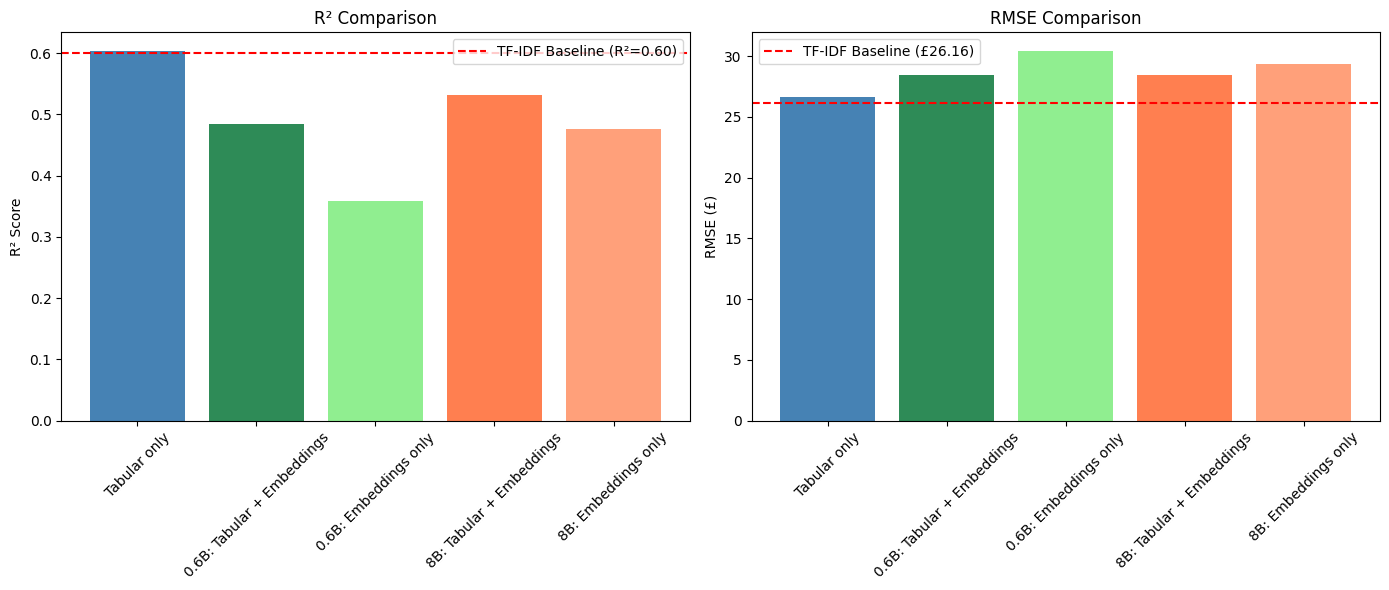

In [5]:
models = list(results.keys())
r2_scores = [results[m][0] for m in models]
rmse_scores = [results[m][1] for m in models]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['steelblue', 'seagreen', 'lightgreen', 'coral', 'lightsalmon']

ax1.bar(models, r2_scores, color=colors)
ax1.axhline(y=0.60, color='red', linestyle='--', label='TF-IDF Baseline (R²=0.60)')
ax1.set_ylabel('R² Score')
ax1.set_title('R² Comparison')
ax1.tick_params(axis='x', rotation=45)
ax1.legend()

ax2.bar(models, rmse_scores, color=colors)
ax2.axhline(y=26.16, color='red', linestyle='--', label='TF-IDF Baseline (£26.16)')
ax2.set_ylabel('RMSE (£)')
ax2.set_title('RMSE Comparison')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

# Wine Dataset - Embeddings de la profesor: Qwen3 0.6B vs 8B

## Goal
Evaluate embeddings generated by professor on GPU using two Qwen3 models:
- `Qwen3-Embedding-0.6B` (1024 dimensions)
- `Qwen3-Embedding-8B` (4096 dimensions)

## Results

| Model | R² | RMSE (£) |
|-------|-----|---------|
| Tabular only | 0.60 | £26.66 |
| TF-IDF Baseline | 0.60 | £26.16 |
| 0.6B: Tabular + Embeddings | 0.48 | £28.44 |
| 0.6B: Embeddings only | 0.36 | £30.43 |
| 8B: Tabular + Embeddings | 0.53 | £28.41 |
| 8B: Embeddings only | 0.48 | £29.33 |

## Observations
- 8B model outperforms 0.6B in all scenarios — larger model = better embeddings
- Embeddings only 8B (R²=0.48) vs 0.6B (R²=0.36) — significant improvement with larger model
- Tabular features alone remain the strongest predictor (R²=0.60)
- Adding embeddings to tabular features hurts performance — Random Forest struggles with high dimensionality (4096 features)
- TF-IDF baseline is still competitive despite being a much simpler method

## Next Steps
- Try dimensionality reduction (PCA/SVD) on embeddings before combining with tabular
- Investigate why adding embeddings hurts combined performance
- Consider neural network models that can better handle high-dimensional embeddings